# Erdos-Renyi G(n, p) and Steinerberger Curvature

This notebook cell imports utilities, builds an Erdos-Renyi graph with fixed seed, and computes Steinerberger curvature.

In [8]:
import sys
from pathlib import Path

repo_root = Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np
import scipy.sparse as sp
from facialgen.curvature import steinerberger_curvature

n = 500
p = 0.5
seed = 1

rng = np.random.default_rng(seed)
upper = np.triu(rng.random((n, n)) < p, k=1)
A = sp.csr_matrix((upper | upper.T).astype(np.float64))

x = steinerberger_curvature(A, use_lcc=False, solver="lstsq", rhs_scale=n)

print(f"A shape: {A.shape}, nnz: {A.nnz}")
print(f"curvature shape: {x.shape}")
print(f"first 10 values: {x[:10]}")
print(f"mean={x.mean():.6f}, std={x.std():.6f}, min={x.min():.6f}, max={x.max():.6f}")

A shape: (500, 500), nnz: 125012
curvature shape: (500,)
first 10 values: [ 2.60882093  0.82409826  7.46821009 -7.47233583  2.64729498  3.89745276
  1.31175921  3.93205991  3.78043104  2.11214217]
mean=0.666371, std=5.990996, min=-17.338616, max=21.002403


## Curvature face counts compared against $p$

In [9]:
# Multi-p curvature comparison at fixed n=500 (with progress bars)
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import importlib
from IPython.display import display
from tqdm.auto import tqdm

import facialgen
import facialgen.curvature as curvature
import facialgen.rotation_systems as rotation_systems

importlib.invalidate_caches()
importlib.reload(facialgen)
importlib.reload(curvature)
importlib.reload(rotation_systems)

from facialgen.curvature import (
    largest_connected_component,
    steinerberger_curvature,
    resistance_curvature,
    ollivier_ricci_curvature,
    lin_lu_yau_curvature,
)
from facialgen.rotation_systems import (
    facial_walks_from_curvature_signs,
    random_rotation_system,
    enumerate_facial_walks_from_rotation,
)

n_fixed = 500
graph_seed = 1
p_values = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]
num_samples = 20

rows = []

for i_p, p_val in enumerate(tqdm(p_values, desc="p sweep")):
    rng_graph = np.random.default_rng(graph_seed + i_p)
    upper = np.triu(rng_graph.random((n_fixed, n_fixed)) < p_val, k=1)
    A_full = sp.csr_matrix((upper | upper.T).astype(np.float64))

    A_lcc, nodes_lcc = largest_connected_component(A_full)
    n_lcc = A_lcc.shape[0]
    undirected_edges_lcc = int(sp.triu(A_lcc, k=1).nnz)
    avg_degree_lcc = (2.0 * undirected_edges_lcc / float(n_lcc)) if n_lcc > 0 else float("nan")

    curvatures = {
        "Steinerberger": steinerberger_curvature(
            A_lcc, use_lcc=False, solver="lstsq", rhs_scale=float(n_lcc)
        ),
        "Resistance": resistance_curvature(
            A_lcc, use_lcc=False, solver="lstsq", rhs_scale=float(n_lcc)
        ),
        "Ollivier-Ricci (approx)": ollivier_ricci_curvature(
            A_lcc, alpha=0.5, max_neighbors=16, edge_sample_size=800, seed=11 + i_p
        ),
        "Lin-Lu-Yau (approx)": lin_lu_yau_curvature(
            A_lcc, alpha_near_one=0.99, max_neighbors=16, edge_sample_size=800, seed=11 + i_p
        ),
    }

    sign_rng = np.random.default_rng(20_000 + i_p)
    sign_samples = sign_rng.choice(
        np.array([-1, 1], dtype=int),
        size=(num_samples, n_lcc),
        replace=True,
    )

    for method_name, curvature_vec in tqdm(
        curvatures.items(), desc=f"methods @ p={p_val:.2f}", leave=False
    ):
        counts = np.empty(num_samples, dtype=int)
        for i in range(num_samples):
            faces = facial_walks_from_curvature_signs(A_lcc, curvature_vec, sign_samples[i])
            counts[i] = len(faces)

        rows.append({
            "p": float(p_val),
            "n_lcc": int(n_lcc),
            "avg_degree": float(avg_degree_lcc),
            "Method": method_name,
            "Mean Faces": float(counts.mean()),
        })

    rand_rot_rng = np.random.default_rng(30_000 + i_p)
    counts_rand = np.empty(num_samples, dtype=int)
    for i in range(num_samples):
        rot_rand = random_rotation_system(A_lcc, rng=rand_rot_rng)
        faces_rand = enumerate_facial_walks_from_rotation(rot_rand)
        counts_rand[i] = len(faces_rand)

    rows.append({
        "p": float(p_val),
        "n_lcc": int(n_lcc),
        "avg_degree": float(avg_degree_lcc),
        "Method": "Random Rotation",
        "Mean Faces": float(counts_rand.mean()),
    })


p sweep:   0%|          | 0/10 [00:00<?, ?it/s]

methods @ p=0.05:   0%|          | 0/4 [00:00<?, ?it/s]

methods @ p=0.10:   0%|          | 0/4 [00:00<?, ?it/s]

methods @ p=0.15:   0%|          | 0/4 [00:00<?, ?it/s]

methods @ p=0.20:   0%|          | 0/4 [00:00<?, ?it/s]

...

methods @ p=0.40:   0%|          | 0/4 [00:00<?, ?it/s]

methods @ p=0.50:   0%|          | 0/4 [00:00<?, ?it/s]

methods @ p=0.60:   0%|          | 0/4 [00:00<?, ?it/s]

methods @ p=0.70:   0%|          | 0/4 [00:00<?, ?it/s]

methods @ p=0.80:   0%|          | 0/4 [00:00<?, ?it/s]

In [10]:
results_long_p = pd.DataFrame(rows)
results_table_p = results_long_p.pivot(
    index=["p", "avg_degree", "n_lcc"],
    columns="Method",
    values="Mean Faces",
).reset_index()

# Display a clean table first.
display(
    results_table_p.style
    .format({c: "{:.2f}" for c in results_table_p.columns if c not in {"p", "avg_degree", "n_lcc"}})
    .format({"p": "{:.2f}", "avg_degree": "{:.2f}"})
)


Method,p,avg_degree,n_lcc,Lin-Lu-Yau (approx),Ollivier-Ricci (approx),Random Rotation,Resistance,Steinerberger
0,0.05,24.98,500,27.800000,17.700000,8.800000,31.900000,27.500000
1,0.10,49.90,500,69.400000,29.400000,9.300000,102.200000,98.900000
2,0.15,75.10,500,129.100000,40.700000,10.700000,230.400000,212.700000
3,0.20,99.56,500,172.000000,35.300000,10.300000,381.900000,376.300000
4,0.30,149.58,500,219.900000,31.600000,11.300000,907.900000,864.400000
5,0.40,200.23,500,280.900000,33.000000,10.400000,1622.300000,1657.500000
6,0.50,249.25,500,360.100000,35.700000,10.100000,2691.700000,2649.200000
7,0.60,298.82,500,441.200000,38.800000,10.300000,4116.400000,4023.700000
8,0.70,349.83,500,538.700000,46.000000,10.800000,6114.600000,5898.000000
9,0.80,399.37,500,597.800000,46.300000,10.600000,8641.900000,8851.700000


## Curvature face counts compared against mean degree


In [11]:
results_table_degree = results_long_p.pivot(
    index=["avg_degree", "p", "n_lcc"],
    columns="Method",
    values="Mean Faces",
).reset_index().sort_values("avg_degree")

display(
    results_table_degree.style
    .format({c: "{:.2f}" for c in results_table_degree.columns if c not in {"avg_degree", "p", "n_lcc"}})
    .format({"avg_degree": "{:.2f}", "p": "{:.2f}"})
)


Method,avg_degree,p,n_lcc,Lin-Lu-Yau (approx),Ollivier-Ricci (approx),Random Rotation,Resistance,Steinerberger
0,24.98,0.05,500,27.800000,17.700000,8.800000,31.900000,27.500000
1,49.90,0.10,500,69.400000,29.400000,9.300000,102.200000,98.900000
2,75.10,0.15,500,129.100000,40.700000,10.700000,230.400000,212.700000
3,99.56,0.20,500,172.000000,35.300000,10.300000,381.900000,376.300000
4,149.58,0.30,500,219.900000,31.600000,11.300000,907.900000,864.400000
5,200.23,0.40,500,280.900000,33.000000,10.400000,1622.300000,1657.500000
6,249.25,0.50,500,360.100000,35.700000,10.100000,2691.700000,2649.200000
7,298.82,0.60,500,441.200000,38.800000,10.300000,4116.400000,4023.700000
8,349.83,0.70,500,538.700000,46.000000,10.800000,6114.600000,5898.000000
9,399.37,0.80,500,597.800000,46.300000,10.600000,8641.900000,8851.700000


## Curvatures face count compared against $n$

In [12]:
# Multi-n curvature comparison at fixed p=0.5 (with progress bars)
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import importlib
from IPython.display import display
from tqdm.auto import tqdm

import facialgen
import facialgen.curvature as curvature
import facialgen.rotation_systems as rotation_systems

importlib.invalidate_caches()
importlib.reload(facialgen)
importlib.reload(curvature)
importlib.reload(rotation_systems)

from facialgen.curvature import (
    largest_connected_component,
    steinerberger_curvature,
    resistance_curvature,
    ollivier_ricci_curvature,
    lin_lu_yau_curvature,
    )
from facialgen.rotation_systems import (
    facial_walks_from_curvature_signs,
    random_rotation_system,
    enumerate_facial_walks_from_rotation,
    )

p_fixed = 0.5
graph_seed = 1
n_values = [80, 120, 160, 220, 300, 400, 500, 700, 850, 1000]
num_samples = 20

rows = []

for i_n, n_val in enumerate(tqdm(n_values, desc="n sweep")):
    # One graph per n at fixed p; all methods below use this same graph.
    rng_graph = np.random.default_rng(graph_seed + i_n)
    upper = np.triu(rng_graph.random((n_val, n_val)) < p_fixed, k=1)
    A_full = sp.csr_matrix((upper | upper.T).astype(np.float64))

    A_lcc, nodes_lcc = largest_connected_component(A_full)
    n_lcc = A_lcc.shape[0]

    curvatures = {
        "Steinerberger": steinerberger_curvature(
            A_lcc, use_lcc=False, solver="lstsq", rhs_scale=float(n_lcc)
        ),
        "Resistance": resistance_curvature(
            A_lcc, use_lcc=False, solver="lstsq", rhs_scale=float(n_lcc)
        ),
        "Ollivier-Ricci (approx)": ollivier_ricci_curvature(
            A_lcc, alpha=0.5, max_neighbors=16, edge_sample_size=800, seed=11 + i_n
        ),
        "Lin-Lu-Yau (approx)": lin_lu_yau_curvature(
            A_lcc, alpha_near_one=0.99, max_neighbors=16, edge_sample_size=800, seed=11 + i_n
        ),
    }

    # Use the same sampled sign assignments for all curvature methods for fairness.
    sign_rng = np.random.default_rng(30_000 + i_n)
    sign_samples = sign_rng.choice(
        np.array([-1, 1], dtype=int),
        size=(num_samples, n_lcc),
        replace=True,
    )

    for method_name, curvature_vec in tqdm(
        curvatures.items(), desc=f"methods @ n={n_val}", leave=False
    ):
        counts = np.empty(num_samples, dtype=int)
        for i in range(num_samples):
            faces = facial_walks_from_curvature_signs(A_lcc, curvature_vec, sign_samples[i])
            counts[i] = len(faces)

        rows.append({
            "n": int(n_lcc),
            "Method": method_name,
            "Mean Faces": float(counts.mean()),
        })

    # Random-rotation baseline on the same graph.
    rand_rot_rng = np.random.default_rng(40_000 + i_n)
    counts_rand = np.empty(num_samples, dtype=int)
    for i in range(num_samples):
        rot_rand = random_rotation_system(A_lcc, rng=rand_rot_rng)
        faces_rand = enumerate_facial_walks_from_rotation(rot_rand)
        counts_rand[i] = len(faces_rand)

    rows.append({
        "n": int(n_lcc),
        "Method": "Random Rotation",
        "Mean Faces": float(counts_rand.mean()),
    })

results_long_n = pd.DataFrame(rows)
results_table_n = results_long_n.pivot(
    index="n",
    columns="Method",
    values="Mean Faces",
).reset_index()

# Display a clean table first.
display(
    results_table_n.style
    .format({c: "{:.2f}" for c in results_table_n.columns if c != "n"})
    .set_caption("Mean Facial Walk Counts by Method (fixed p=0.5, varying n)")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center"), ("font-weight", "bold")]},
        {"selector": "caption", "props": [("caption-side", "top"), ("font-size", "1.05em"), ("font-weight", "bold")]},
    ])
)


n sweep:   0%|          | 0/10 [00:00<?, ?it/s]

methods @ n=80:   0%|          | 0/4 [00:00<?, ?it/s]

methods @ n=120:   0%|          | 0/4 [00:00<?, ?it/s]

methods @ n=160:   0%|          | 0/4 [00:00<?, ?it/s]

methods @ n=220:   0%|          | 0/4 [00:00<?, ?it/s]

...

methods @ n=500:   0%|          | 0/4 [00:00<?, ?it/s]

methods @ n=700:   0%|          | 0/4 [00:00<?, ?it/s]

methods @ n=850:   0%|          | 0/4 [00:00<?, ?it/s]

methods @ n=1000:   0%|          | 0/4 [00:00<?, ?it/s]

Method,n,Lin-Lu-Yau (approx),Ollivier-Ricci (approx),Random Rotation,Resistance,Steinerberger
0,80,79.60,52.70,6.60,76.00,85.70
1,120,160.30,67.60,8.10,154.10,159.90
2,160,269.20,108.70,8.90,303.20,285.80
3,220,437.60,86.60,10.10,518.20,500.30
4,300,511.70,81.90,9.40,997.00,974.50
5,400,480.90,56.50,9.80,1745.80,1749.60
6,500,358.20,35.80,10.80,2660.20,2638.70
7,700,195.60,20.40,11.60,5263.30,5265.90
8,850,178.70,17.40,11.20,7683.50,7717.50
9,1000,138.80,17.30,12.00,10667.60,10644.70


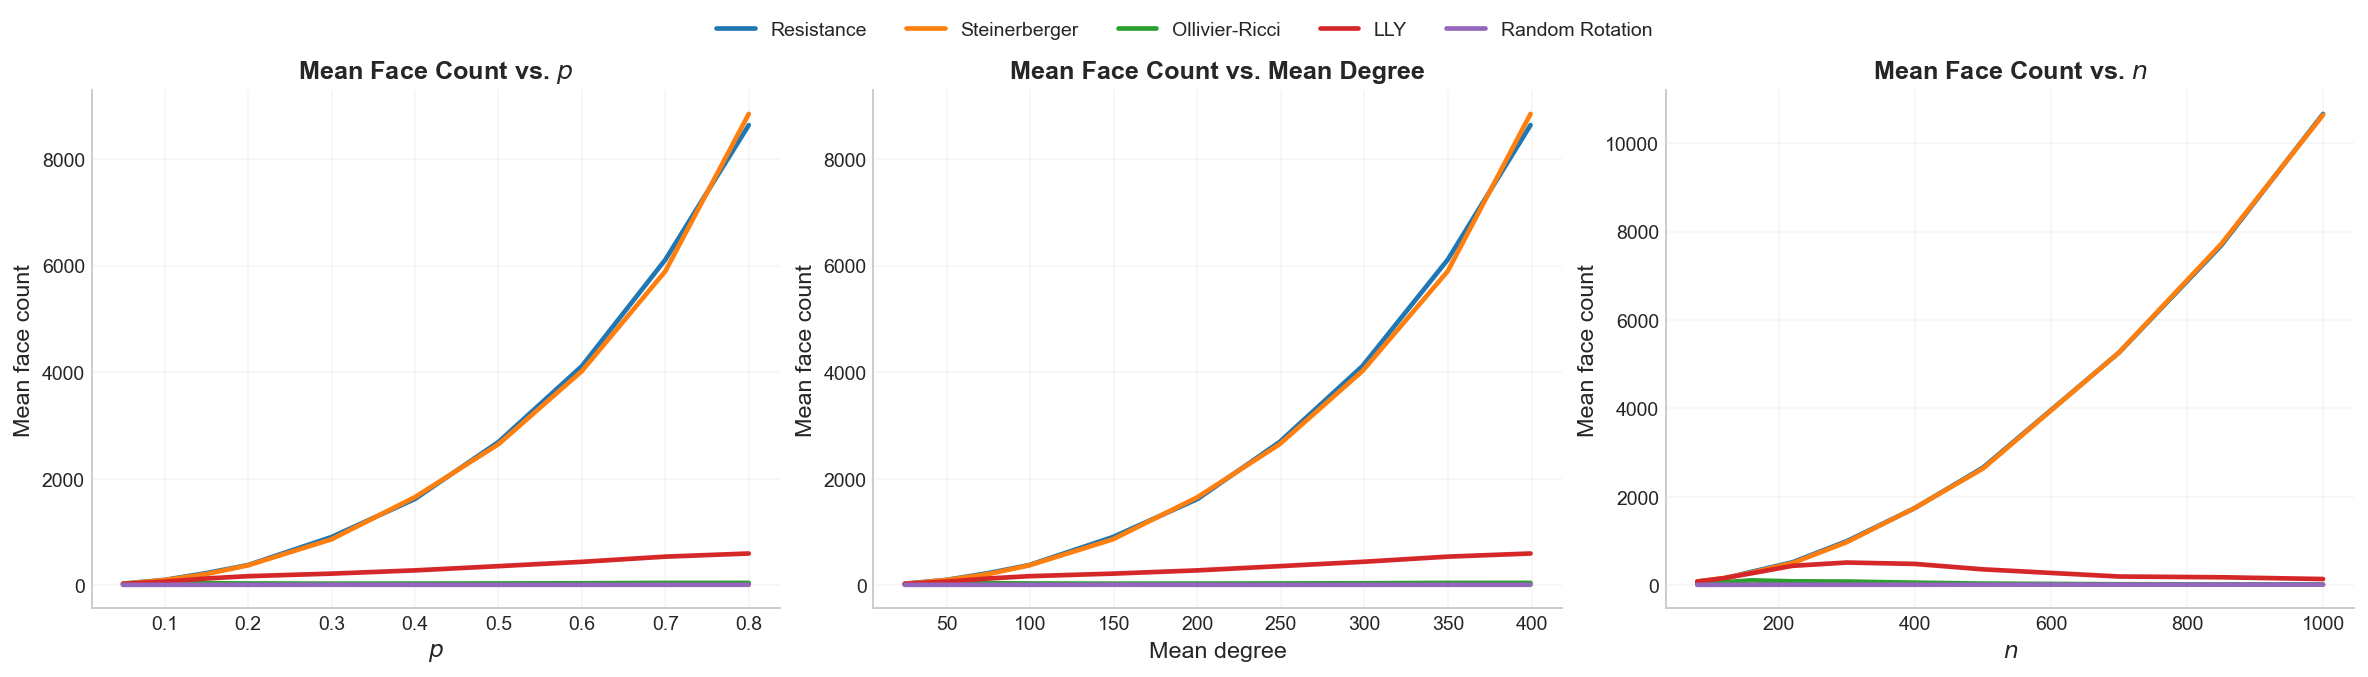

In [13]:
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
mpl.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "axes.titleweight": "semibold",
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 2.4,
    "grid.alpha": 0.18,
    "grid.linewidth": 0.8,
})

method_order = [
    "Resistance",
    "Steinerberger",
    "Ollivier-Ricci",
    "LLY",
    "Random Rotation",
]
label_map = {
    "Resistance": "Resistance",
    "Steinerberger": "Steinerberger",
    "Ollivier-Ricci (approx)": "Ollivier-Ricci",
    "Ollivier-Ricci": "Ollivier-Ricci",
    "Lin-Lu-Yau (approx)": "LLY",
    "LLY (approx)": "LLY",
    "LLY": "LLY",
    "Random Rotation": "Random Rotation",
}

if "results_table_p" not in globals() or "results_table_n" not in globals() or "results_table_degree" not in globals():
    raise RuntimeError("Run the p-sweep table cell, mean-degree table cell, and n-sweep cell first so all summary tables exist.")

p_plot = results_table_p.rename(columns=label_map).copy()
d_plot = results_table_degree.rename(columns=label_map).copy()
n_plot = results_table_n.rename(columns=label_map).copy()

palette = plt.get_cmap("tab10")
color_map = {method: palette(i % 10) for i, method in enumerate(method_order)}

fig, axes = plt.subplots(1, 3, figsize=(16.8, 4.4), constrained_layout=True)
ax_p, ax_d, ax_n = axes

for method in method_order:
    if method in p_plot.columns:
        ax_p.plot(
            p_plot["p"],
            p_plot[method],
            color=color_map[method],
            label=method,
        )
    if method in d_plot.columns:
        ax_d.plot(
            d_plot["avg_degree"],
            d_plot[method],
            color=color_map[method],
            label=method,
        )
    if method in n_plot.columns:
        ax_n.plot(
            n_plot["n"],
            n_plot[method],
            color=color_map[method],
            label=method,
        )

ax_p.set_title("Mean Face Count vs. $p$")
ax_p.set_xlabel("$p$")
ax_p.set_ylabel("Mean face count")

ax_d.set_title("Mean Face Count vs. Mean Degree")
ax_d.set_xlabel("Mean degree")
ax_d.set_ylabel("Mean face count")

ax_n.set_title("Mean Face Count vs. $n$")
ax_n.set_xlabel("$n$")
ax_n.set_ylabel("Mean face count")

handles, labels = ax_p.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    frameon=False,
    loc="upper center",
    ncol=min(len(labels), 5),
    bbox_to_anchor=(0.5, 1.08),
)
plt.show()


# CoraML Experiments

In [3]:
import numpy as np
import pandas as pd
from IPython.display import display

from facialgen.data import load_graph_dataset_sparse
from facialgen.curvature import (
    largest_connected_component,
    steinerberger_curvature,
    resistance_curvature,
    ollivier_ricci_curvature,
    lin_lu_yau_curvature,
)
from facialgen.rotation_systems import (
    facial_walks_from_curvature_signs,
    random_rotation_system,
    enumerate_facial_walks_from_rotation,
)

A_full, X, y = load_graph_dataset_sparse("coraml", data_dir="data")
A_lcc, nodes_lcc = largest_connected_component(A_full)
n_lcc = A_lcc.shape[0]

curvatures = {
    "Steinerberger": steinerberger_curvature(
        A_lcc, use_lcc=False, solver="lstsq", rhs_scale=float(n_lcc)
    ),
    "Resistance": resistance_curvature(
        A_lcc, use_lcc=False, solver="lstsq", rhs_scale=float(n_lcc)
    ),
    "Ollivier-Ricci (approx)": ollivier_ricci_curvature(
        A_lcc, alpha=0.5, max_neighbors=16, edge_sample_size=1500, seed=101
    ),
    "Lin-Lu-Yau (approx)": lin_lu_yau_curvature(
        A_lcc,
        alpha_near_one=0.99,
        max_neighbors=16,
        edge_sample_size=1500,
        seed=101,
    ),
}

num_samples = 20
sign_rng = np.random.default_rng(2026)
sign_samples = sign_rng.choice(
    np.array([-1, 1], dtype=int),
    size=(num_samples, n_lcc),
    replace=True,
)

rows = []

for method_name, curvature_vec in curvatures.items():
    counts = np.empty(num_samples, dtype=int)
    for i in range(num_samples):
        faces = facial_walks_from_curvature_signs(A_lcc, curvature_vec, sign_samples[i])
        counts[i] = len(faces)

    rows.append({
        "Method": method_name,
        "Mean Faces": float(counts.mean()),
        "Std Faces": float(counts.std()),
        "Min Faces": int(counts.min()),
        "Max Faces": int(counts.max()),
    })

rand_rot_rng = np.random.default_rng(404)
counts_rand = np.empty(num_samples, dtype=int)
for i in range(num_samples):
    rot_rand = random_rotation_system(A_lcc, rng=rand_rot_rng)
    faces_rand = enumerate_facial_walks_from_rotation(rot_rand)
    counts_rand[i] = len(faces_rand)

rows.append({
    "Method": "Random Rotation",
    "Mean Faces": float(counts_rand.mean()),
    "Std Faces": float(counts_rand.std()),
    "Min Faces": int(counts_rand.min()),
    "Max Faces": int(counts_rand.max()),
})

results = pd.DataFrame(rows).sort_values("Method").reset_index(drop=True)
display(
    results.style
    .format({"Mean Faces": "{:.2f}", "Std Faces": "{:.2f}"})
    .set_caption("CoraML facial-walk counts: curvature-based +/- vs random rotation")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center"), ("font-weight", "bold")]},
        {"selector": "caption", "props": [("caption-side", "top"), ("font-size", "1.05em"), ("font-weight", "bold")]},
    ])
)


,Method,Mean Faces,Std Faces,Min Faces,Max Faces
0,Lin-Lu-Yau (approx),149.00,10.60,125,169
1,Ollivier-Ricci (approx),146.80,11.38,127,167
2,Random Rotation,90.00,10.54,71,123
3,Resistance,199.50,13.71,179,223
4,Steinerberger,182.40,11.03,153,199


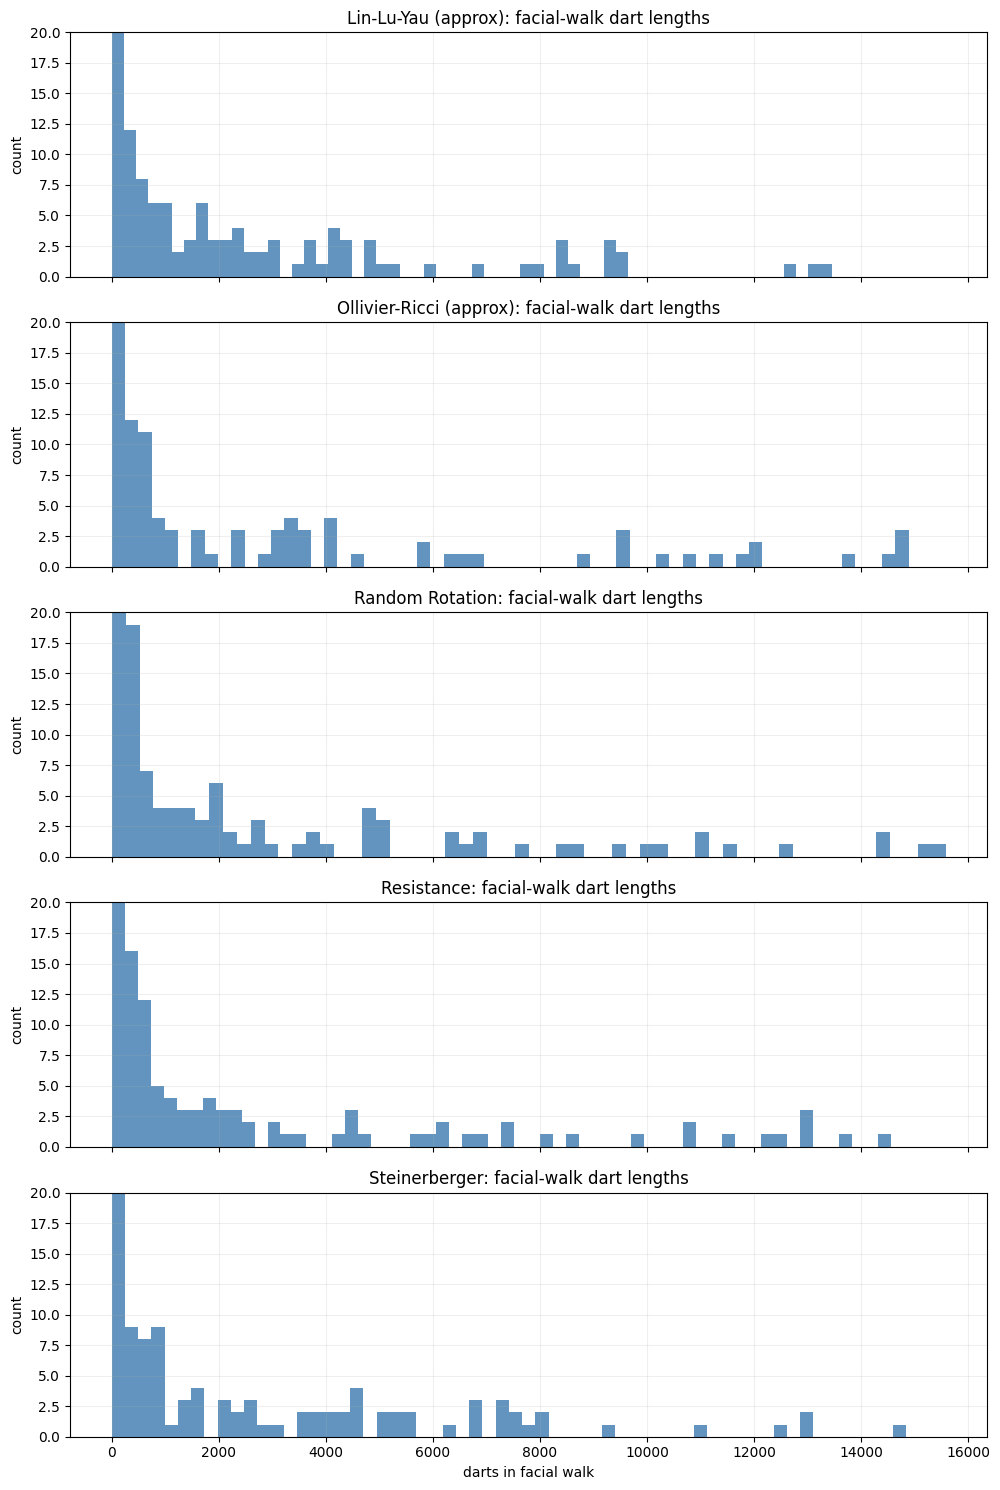

,Method,Mean Dart Length,Median Dart Length,Max Dart Length,Num Faces Sampled
0,Lin-Lu-Yau (approx),107.127517,4.0,13450,2980
1,Ollivier-Ricci (approx),108.732970,4.0,14886,2936
2,Random Rotation,177.355556,4.0,15578,1800
3,Resistance,80.010025,4.0,14553,3990
4,Steinerberger,87.510965,4.0,14840,3648


In [3]:
import matplotlib.pyplot as plt
length_samples = {}

for method_name, curvature_vec in curvatures.items():
    method_lengths = []
    for i in range(num_samples):
        faces = facial_walks_from_curvature_signs(A_lcc, curvature_vec, sign_samples[i])
        method_lengths.extend(len(face) for face in faces)
    length_samples[method_name] = np.asarray(method_lengths, dtype=int)

rand_rot_rng = np.random.default_rng(404)
rand_lengths = []
for i in range(num_samples):
    rot_rand = random_rotation_system(A_lcc, rng=rand_rot_rng)
    faces_rand = enumerate_facial_walks_from_rotation(rot_rand)
    rand_lengths.extend(len(face) for face in faces_rand)
length_samples['Random Rotation'] = np.asarray(rand_lengths, dtype=int)

fig, axes = plt.subplots(
    len(length_samples),
    1,
    figsize=(10, 3.0 * len(length_samples)),
    sharex=True,
)
axes = np.atleast_1d(axes)

for ax, (method_name, lengths) in zip(axes, sorted(length_samples.items())):
    ax.hist(lengths, bins=60, color="steelblue", alpha=0.85)
    ax.set_title(f"{method_name}: facial-walk dart lengths")
    ax.set_ylabel("count")
    ax.grid(alpha=0.2)
    ax.set_ylim(0, 20)

axes[-1].set_xlabel("darts in facial walk")
plt.tight_layout()
plt.show()

display(pd.DataFrame([
    {
        "Method": method_name,
        "Mean Dart Length": float(lengths.mean()),
        "Median Dart Length": float(np.median(lengths)),
        "Max Dart Length": int(lengths.max()),
        "Num Faces Sampled": int(lengths.size),
    }
    for method_name, lengths in sorted(length_samples.items())
]))


## Local 8-Dart Chunk Diversity

For each curvature method, plus a **purely random rotation-system baseline**, we sample many sign configurations/rotations, generate the full facial walks, split them into **exact 8-dart chunks** (without `BOS`), and compare their local diversity against matched-count second-order random walks of 8 darts on the same graph. We report unique chunk counts, pairwise dart-sequence Hamming distance, per-position entropy, and cumulative unique-dart coverage.


facial chunk methods:   0%|          | 0/5 [00:00<?, ?it/s]

Lin-Lu-Yau (approx): samples:   0%|          | 0/20 [00:00<?, ?it/s]

Lin-Lu-Yau (approx): random chunks:   0%|          | 0/38596 [00:00<?, ?it/s]

Ollivier-Ricci (approx): samples:   0%|          | 0/20 [00:00<?, ?it/s]

Ollivier-Ricci (approx): random chunks:   0%|          | 0/38600 [00:00<?, ?it/s]

...

Steinerberger: samples:   0%|          | 0/20 [00:00<?, ?it/s]

Steinerberger: random chunks:   0%|          | 0/38254 [00:00<?, ?it/s]

Random Rotation: samples:   0%|          | 0/20 [00:00<?, ?it/s]

Random Rotation: random chunks:   0%|          | 0/39110 [00:00<?, ?it/s]

,Method,Mean Faces,Std Faces,Max Faces,Num Facial Chunks,Unique Facial Chunk Ratio,Random Walk Unique Chunk Ratio
0,Lin-Lu-Yau (approx),147.7,7.383089,163.0,38596,0.929475,0.997901
1,Ollivier-Ricci (approx),147.2,7.997500,167.0,38600,0.928187,0.997591
2,Random Rotation,88.1,8.257724,103.0,39110,0.999489,0.998185
3,Resistance,199.3,12.763620,229.0,38049,0.965676,0.997608
4,Steinerberger,180.0,10.573552,197.0,38254,0.968082,0.997752


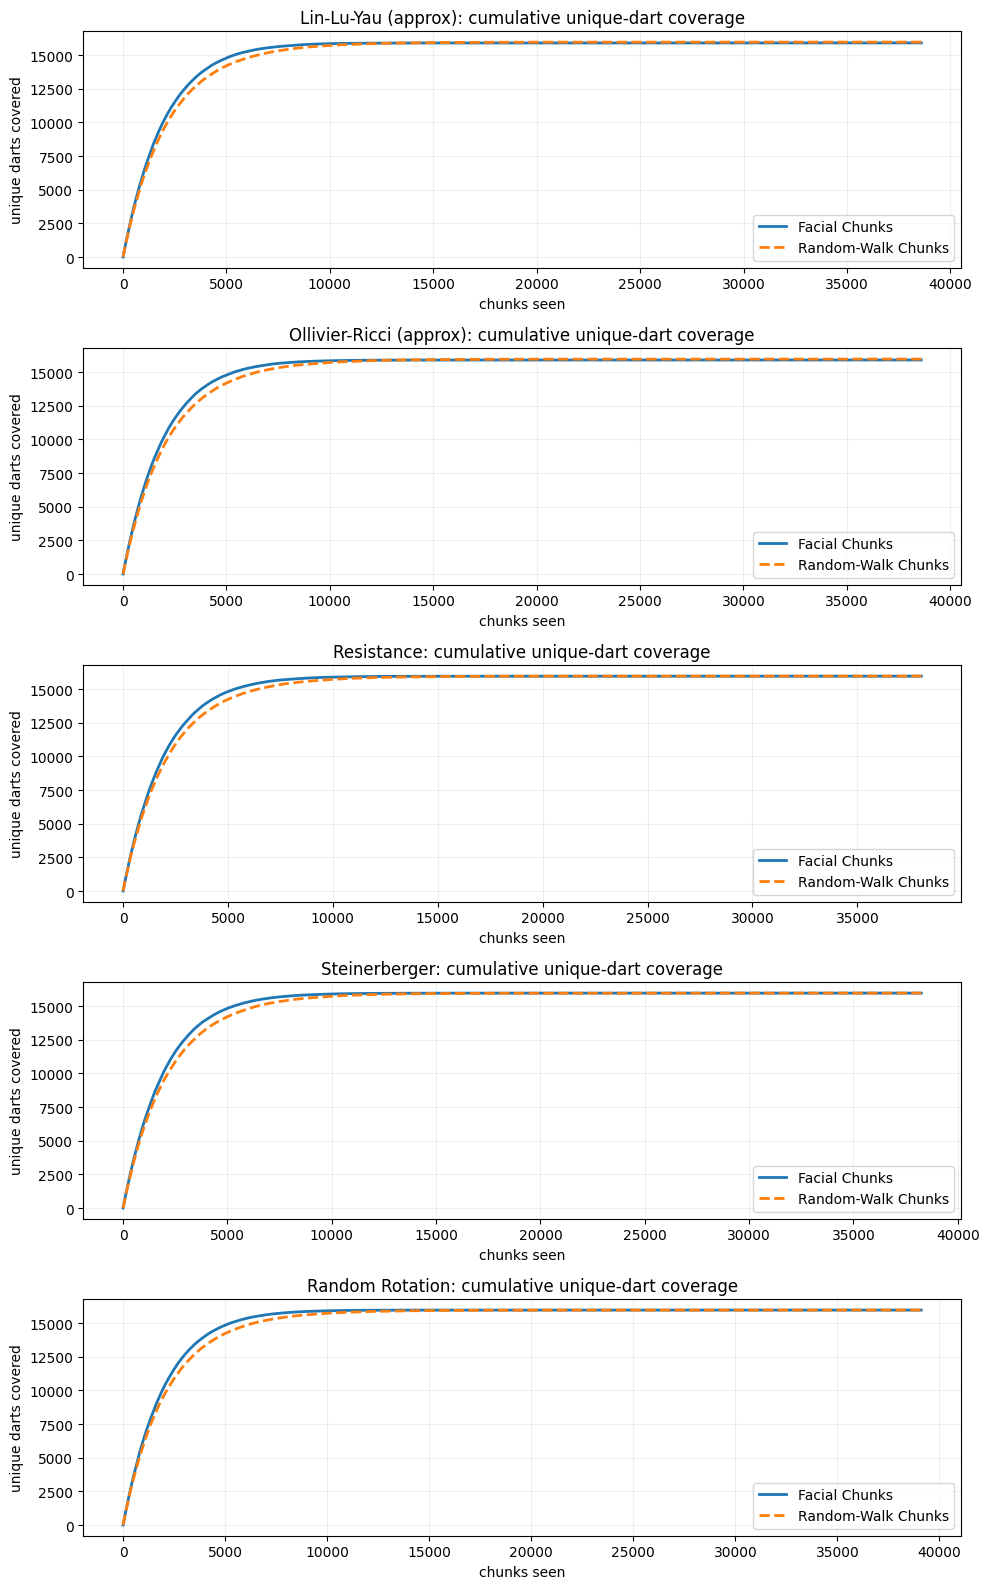

In [4]:
import pandas as pd

curvature_df = pd.read_csv("curvature_results.csv")
curvature_df


## Random-Walk Dart Coverage

This cell isolates the **coverage** question: how many second-order random walks of length 8 are needed before we have seen every directed dart in the graph at least once? For comparison, a full facial decomposition of a single rotation system covers all darts deterministically, so the rough facial chunk budget is just `num_darts / 8`.


random-walk coverage trials:   0%|          | 0/8 [00:00<?, ?it/s]

number of walks:   0%|          | 0/15000 [00:00<?, ?it/s]

number of walks:   0%|          | 0/15000 [00:00<?, ?it/s]

number of walks:   0%|          | 0/15000 [00:00<?, ?it/s]

number of walks:   0%|          | 0/15000 [00:00<?, ?it/s]

...

number of walks:   0%|          | 0/15000 [00:00<?, ?it/s]

number of walks:   0%|          | 0/15000 [00:00<?, ?it/s]

number of walks:   0%|          | 0/15000 [00:00<?, ?it/s]

,Total Directed Darts,Facial Full-Coverage 8-Dart Chunks,Random-Walk Mean Chunks to Full Coverage,Random-Walk Median Chunks to Full Coverage,Random-Walk Min Chunks to Full Coverage,Random-Walk Max Chunks to Full Coverage
0,15962,1996,NaN,NaN,NaN,NaN


,trial,random_walk_chunks_to_full_coverage
0,1,NaN
1,2,NaN
2,3,NaN
3,4,NaN
4,5,NaN
5,6,NaN
6,7,NaN
7,8,NaN


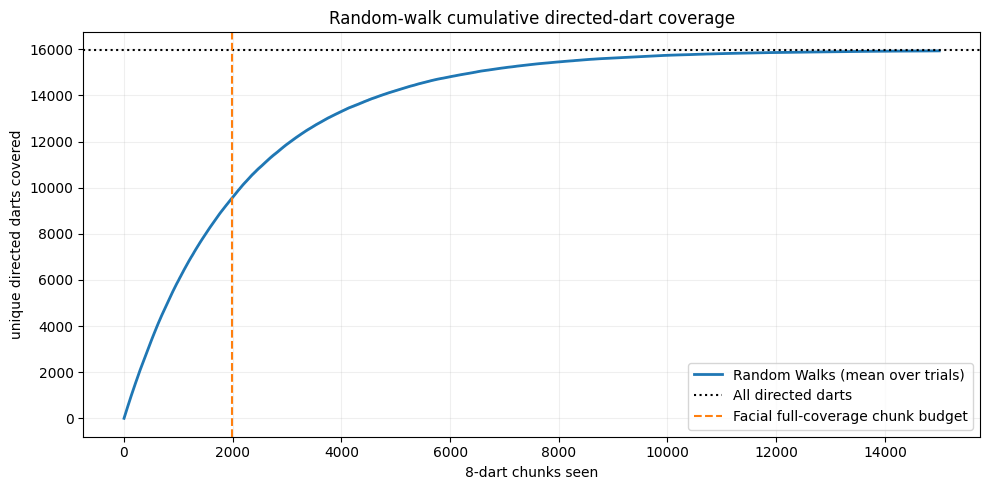

In [5]:
from math import ceil
from tqdm.auto import tqdm

coverage_trials = 8
coverage_max_walks = 15_000
coverage_rng_seed = 3031

rows, cols = A_lcc.nonzero()
all_darts = {(int(u), int(v)) for u, v in zip(rows.tolist(), cols.tolist()) if int(u) != int(v)}
num_darts_total = len(all_darts)
facial_full_coverage_chunks = ceil(num_darts_total / chunk_darts)

def random_walk_coverage_curve(A, *, num_darts, p, q, max_walks, rng):
    seen = set()
    curve = np.empty(max_walks, dtype=float)
    reached_at = None
    for walk_idx in tqdm(range(max_walks), desc='number of walks'):
        chunk = second_order_random_walk_chunk(A, num_darts, rng, p=p, q=q)
        seen.update(chunk)
        curve[walk_idx] = len(seen)
        if reached_at is None and len(seen) >= num_darts_total:
            reached_at = walk_idx + 1
            curve[walk_idx:] = len(seen)
            break
    return curve, reached_at

coverage_curves_rw = []
coverage_hits = []
trial_rng = np.random.default_rng(coverage_rng_seed)

for trial_idx in tqdm(range(coverage_trials), desc='random-walk coverage trials'):
    curve, reached_at = random_walk_coverage_curve(
        A_lcc,
        num_darts=chunk_darts,
        p=rw_p,
        q=rw_q,
        max_walks=coverage_max_walks,
        rng=np.random.default_rng(int(trial_rng.integers(0, 2**32 - 1))),
    )
    coverage_curves_rw.append(curve)
    coverage_hits.append(reached_at if reached_at is not None else np.nan)

coverage_curves_rw = np.asarray(coverage_curves_rw, dtype=float)
mean_curve_rw = np.nanmean(coverage_curves_rw, axis=0)
std_curve_rw = np.nanstd(coverage_curves_rw, axis=0)
coverage_hits = np.asarray(coverage_hits, dtype=float)

summary_df = pd.DataFrame([{
    'Total Directed Darts': int(num_darts_total),
    'Facial Full-Coverage 8-Dart Chunks': int(facial_full_coverage_chunks),
    'Random-Walk Mean Chunks to Full Coverage': float(np.nanmean(coverage_hits)) if np.isfinite(coverage_hits).any() else float('nan'),
    'Random-Walk Median Chunks to Full Coverage': float(np.nanmedian(coverage_hits)) if np.isfinite(coverage_hits).any() else float('nan'),
    'Random-Walk Min Chunks to Full Coverage': float(np.nanmin(coverage_hits)) if np.isfinite(coverage_hits).any() else float('nan'),
    'Random-Walk Max Chunks to Full Coverage': float(np.nanmax(coverage_hits)) if np.isfinite(coverage_hits).any() else float('nan'),
}])
display(summary_df)

trial_rows = pd.DataFrame({
    'trial': np.arange(1, coverage_trials + 1),
    'random_walk_chunks_to_full_coverage': coverage_hits,
})
display(trial_rows)

x = np.arange(1, coverage_max_walks + 1)
plt.figure(figsize=(10, 5))
plt.plot(x, mean_curve_rw, label='Random Walks (mean over trials)', linewidth=2)
plt.fill_between(x, mean_curve_rw - std_curve_rw, mean_curve_rw + std_curve_rw, alpha=0.2)
plt.axhline(num_darts_total, color='black', linestyle=':', label='All directed darts')
plt.axvline(facial_full_coverage_chunks, color='tab:orange', linestyle='--', label='Facial full-coverage chunk budget')
plt.xlabel('8-dart chunks seen')
plt.ylabel('unique directed darts covered')
plt.title('Random-walk cumulative directed-dart coverage')
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()


## Resistance-Only Chunk Diversity

Use this cell to rerun the local 8-dart chunk diversity comparison for **resistance curvature only**, with a larger number of sign configurations if desired.


Resistance: sign configs:   0%|          | 0/256 [00:00<?, ?it/s]

Resistance: random chunks:   0%|          | 0/487080 [00:00<?, ?it/s]

,Method,Num Sign Configs,Num Facial Chunks,Unique Facial 8-Dart Chunks,Facial Unique Chunk Ratio,Facial Mean Pairwise Hamming,Facial Std Pairwise Hamming,Facial Mean Position Entropy,Facial Final Unique Dart Coverage,Unique Random 8-Dart Chunks,Random Unique Chunk Ratio,Random Mean Pairwise Hamming,Random Std Pairwise Hamming,Random Mean Position Entropy,Random Final Unique Dart Coverage
0,Resistance,256,487080,363731,0.746758,7.99915,0.052434,13.928253,15954.0,481174,0.987875,7.9993,0.031615,13.782043,15962.0


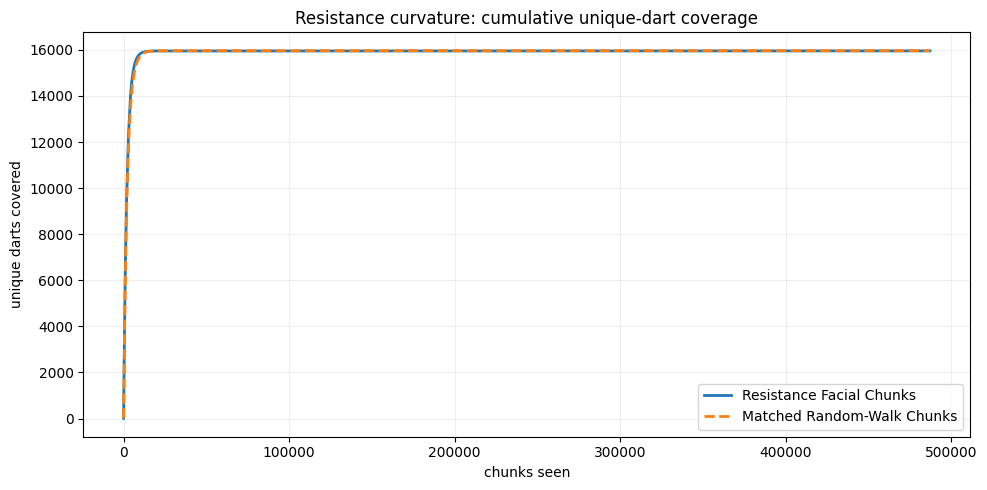

In [6]:
resistance_num_sign_configs = 256
resistance_pairwise_hamming_pairs = 20000
resistance_coverage_shuffles = 8
resistance_rng = np.random.default_rng(4041)

resistance_curv = curvatures['Resistance']
resistance_sign_samples = resistance_rng.choice(
    np.array([-1, 1], dtype=int),
    size=(resistance_num_sign_configs, n_lcc),
    replace=True,
)

resistance_facial_chunks = []
for i in tqdm(range(resistance_num_sign_configs), desc='Resistance: sign configs'):
    faces = facial_walks_from_curvature_signs(A_lcc, resistance_curv, resistance_sign_samples[i])
    for face in faces:
        resistance_facial_chunks.extend(chunk_face_exact(face, chunk_darts=chunk_darts))

resistance_rw_chunks = sample_random_walk_chunks(
    A_lcc,
    num_chunks=len(resistance_facial_chunks),
    num_darts=chunk_darts,
    rng=np.random.default_rng(5051),
    p=rw_p,
    q=rw_q,
    desc='Resistance: random chunks',
)

resistance_facial_hammings = sample_pairwise_hamming(
    resistance_facial_chunks,
    np.random.default_rng(6061),
    max_pairs=resistance_pairwise_hamming_pairs,
)
resistance_rw_hammings = sample_pairwise_hamming(
    resistance_rw_chunks,
    np.random.default_rng(7071),
    max_pairs=resistance_pairwise_hamming_pairs,
)
resistance_facial_ent = per_position_entropy(resistance_facial_chunks)
resistance_rw_ent = per_position_entropy(resistance_rw_chunks)
resistance_facial_curve = mean_coverage_curve(
    resistance_facial_chunks,
    np.random.default_rng(8081),
    num_shuffles=resistance_coverage_shuffles,
)
resistance_rw_curve = mean_coverage_curve(
    resistance_rw_chunks,
    np.random.default_rng(9091),
    num_shuffles=resistance_coverage_shuffles,
)

resistance_results = pd.DataFrame([{
    'Method': 'Resistance',
    'Num Sign Configs': int(resistance_num_sign_configs),
    'Num Facial Chunks': int(len(resistance_facial_chunks)),
    'Unique Facial 8-Dart Chunks': int(len(set(resistance_facial_chunks))),
    'Facial Unique Chunk Ratio': unique_chunk_ratio(resistance_facial_chunks),
    'Facial Mean Pairwise Hamming': float(np.nanmean(resistance_facial_hammings)) if resistance_facial_hammings.size else float('nan'),
    'Facial Std Pairwise Hamming': float(np.nanstd(resistance_facial_hammings)) if resistance_facial_hammings.size else float('nan'),
    'Facial Mean Position Entropy': float(np.nanmean(resistance_facial_ent)) if resistance_facial_ent.size else float('nan'),
    'Facial Final Unique Dart Coverage': float(resistance_facial_curve[-1]) if resistance_facial_curve.size else float('nan'),
    'Unique Random 8-Dart Chunks': int(len(set(resistance_rw_chunks))),
    'Random Unique Chunk Ratio': unique_chunk_ratio(resistance_rw_chunks),
    'Random Mean Pairwise Hamming': float(np.nanmean(resistance_rw_hammings)) if resistance_rw_hammings.size else float('nan'),
    'Random Std Pairwise Hamming': float(np.nanstd(resistance_rw_hammings)) if resistance_rw_hammings.size else float('nan'),
    'Random Mean Position Entropy': float(np.nanmean(resistance_rw_ent)) if resistance_rw_ent.size else float('nan'),
    'Random Final Unique Dart Coverage': float(resistance_rw_curve[-1]) if resistance_rw_curve.size else float('nan'),
}])
display(resistance_results)

plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(resistance_facial_curve) + 1), resistance_facial_curve, label='Resistance Facial Chunks', linewidth=2)
plt.plot(np.arange(1, len(resistance_rw_curve) + 1), resistance_rw_curve, label='Matched Random-Walk Chunks', linewidth=2, linestyle='--')
plt.title('Resistance curvature: cumulative unique-dart coverage')
plt.xlabel('chunks seen')
plt.ylabel('unique darts covered')
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()


## Random Rotation vs Random Walk Unique Chunk Ratio

Compare only the unique 8-dart chunk ratio for random-rotation facial walks against matched-count second-order random walks.


In [9]:
from tqdm.auto import tqdm

from facialgen.rotation_systems import enumerate_facial_walks_from_rotation, random_rotation_system

random_rotation_num_systems = 256
random_rotation_seed = 2026
random_walk_seed = 2026
random_walk_p = 1.0
random_walk_q = 1.0
chunk_darts = 8

A_eval = A_lcc.copy().tocsr()


def chunk_face_exact_local(face, chunk_darts=8):
    face = [(int(u), int(v)) for (u, v) in face]
    num_full_chunks = len(face) // int(chunk_darts)
    return [tuple(face[i * chunk_darts:(i + 1) * chunk_darts]) for i in range(num_full_chunks)]


def second_order_random_walk_chunk_local(A, num_darts, rng, p=1.0, q=1.0):
    A = A.tocsr()
    deg = np.diff(A.indptr)
    valid_nodes = np.flatnonzero(deg > 0)
    if valid_nodes.size == 0:
        return tuple()
    cur = int(rng.choice(valid_nodes))
    darts = []
    row_start, row_stop = A.indptr[cur], A.indptr[cur + 1]
    nbrs = A.indices[row_start:row_stop]
    nxt = int(rng.choice(nbrs))
    darts.append((cur, nxt))
    prev, cur = cur, nxt
    neighbor_sets = None
    for _ in range(1, int(num_darts)):
        row_start, row_stop = A.indptr[cur], A.indptr[cur + 1]
        nbrs = A.indices[row_start:row_stop]
        if nbrs.size == 0:
            break
        if neighbor_sets is None:
            neighbor_sets = [set(map(int, A.indices[A.indptr[i]:A.indptr[i + 1]].tolist())) for i in range(A.shape[0])]
        weights = np.empty(nbrs.size, dtype=float)
        prev_is_neighbor = neighbor_sets[prev]
        for i, x in enumerate(nbrs):
            x = int(x)
            if x == prev:
                weights[i] = 1.0 / max(float(p), 1e-12)
            elif x in prev_is_neighbor:
                weights[i] = 1.0
            else:
                weights[i] = 1.0 / max(float(q), 1e-12)
        weights = weights / weights.sum()
        nxt = int(rng.choice(nbrs, p=weights))
        darts.append((cur, nxt))
        prev, cur = cur, nxt
    return tuple(darts)


def sample_random_walk_chunks_exact_local(A, num_chunks, walk_darts, p=1.0, q=1.0, seed=2026):
    rng = np.random.default_rng(seed)
    return [
        second_order_random_walk_chunk_local(A, num_darts=walk_darts, rng=rng, p=p, q=q)
        for _ in tqdm(range(int(num_chunks)), desc='Random walk chunks', leave=False)
    ]


def unique_chunk_ratio_local(chunks):
    chunks = [tuple(chunk) for chunk in chunks if len(chunk) > 0]
    if not chunks:
        return float('nan')
    return len(set(chunks)) / len(chunks)


rng = np.random.default_rng(random_rotation_seed)
random_rotation_faces = []
for _ in tqdm(range(int(random_rotation_num_systems)), desc='Random rotations', leave=False):
    rotation = random_rotation_system(A_eval, rng=rng)
    faces = enumerate_facial_walks_from_rotation(rotation)
    random_rotation_faces.extend(faces)

random_rotation_chunks = []
for face in random_rotation_faces:
    random_rotation_chunks.extend(chunk_face_exact_local(face, chunk_darts=chunk_darts))

num_chunks = len(random_rotation_chunks)
matched_random_chunks = sample_random_walk_chunks_exact_local(
    A_eval,
    num_chunks=num_chunks,
    walk_darts=chunk_darts,
    p=float(random_walk_p),
    q=float(random_walk_q),
    seed=int(random_walk_seed),
)

rotation_unique_ratio = unique_chunk_ratio_local(random_rotation_chunks)
walk_unique_ratio = unique_chunk_ratio_local(matched_random_chunks)

compare_df = pd.DataFrame([
    {
        'Method': 'Random Rotation',
        'Num Chunks': int(num_chunks),
        'Unique Chunk Ratio': float(rotation_unique_ratio),
    },
    {
        'Method': 'Second-Order Random Walk',
        'Num Chunks': int(len(matched_random_chunks)),
        'Unique Chunk Ratio': float(walk_unique_ratio),
    },
])

print(compare_df.to_string(index=False))
display(compare_df)


Random rotations:   0%|          | 0/256 [00:00<?, ?it/s]

Random walk chunks:   0%|          | 0/500696 [00:00<?, ?it/s]

                  Method  Num Chunks  Unique Chunk Ratio
         Random Rotation      500696            0.994645
Second-Order Random Walk      500696            0.987575


,Method,Num Chunks,Unique Chunk Ratio
0,Random Rotation,500696,0.994645
1,Second-Order Random Walk,500696,0.987575
